--- Matriz de Correlação ---
             sales    profit  discount  quantity
sales     1.000000  0.328614  0.010667  0.024208
profit    0.328614  1.000000 -0.794918 -0.023943
discount  0.010667 -0.794918  1.000000  0.026936
quantity  0.024208 -0.023943  0.026936  1.000000
--------------------------------------------------


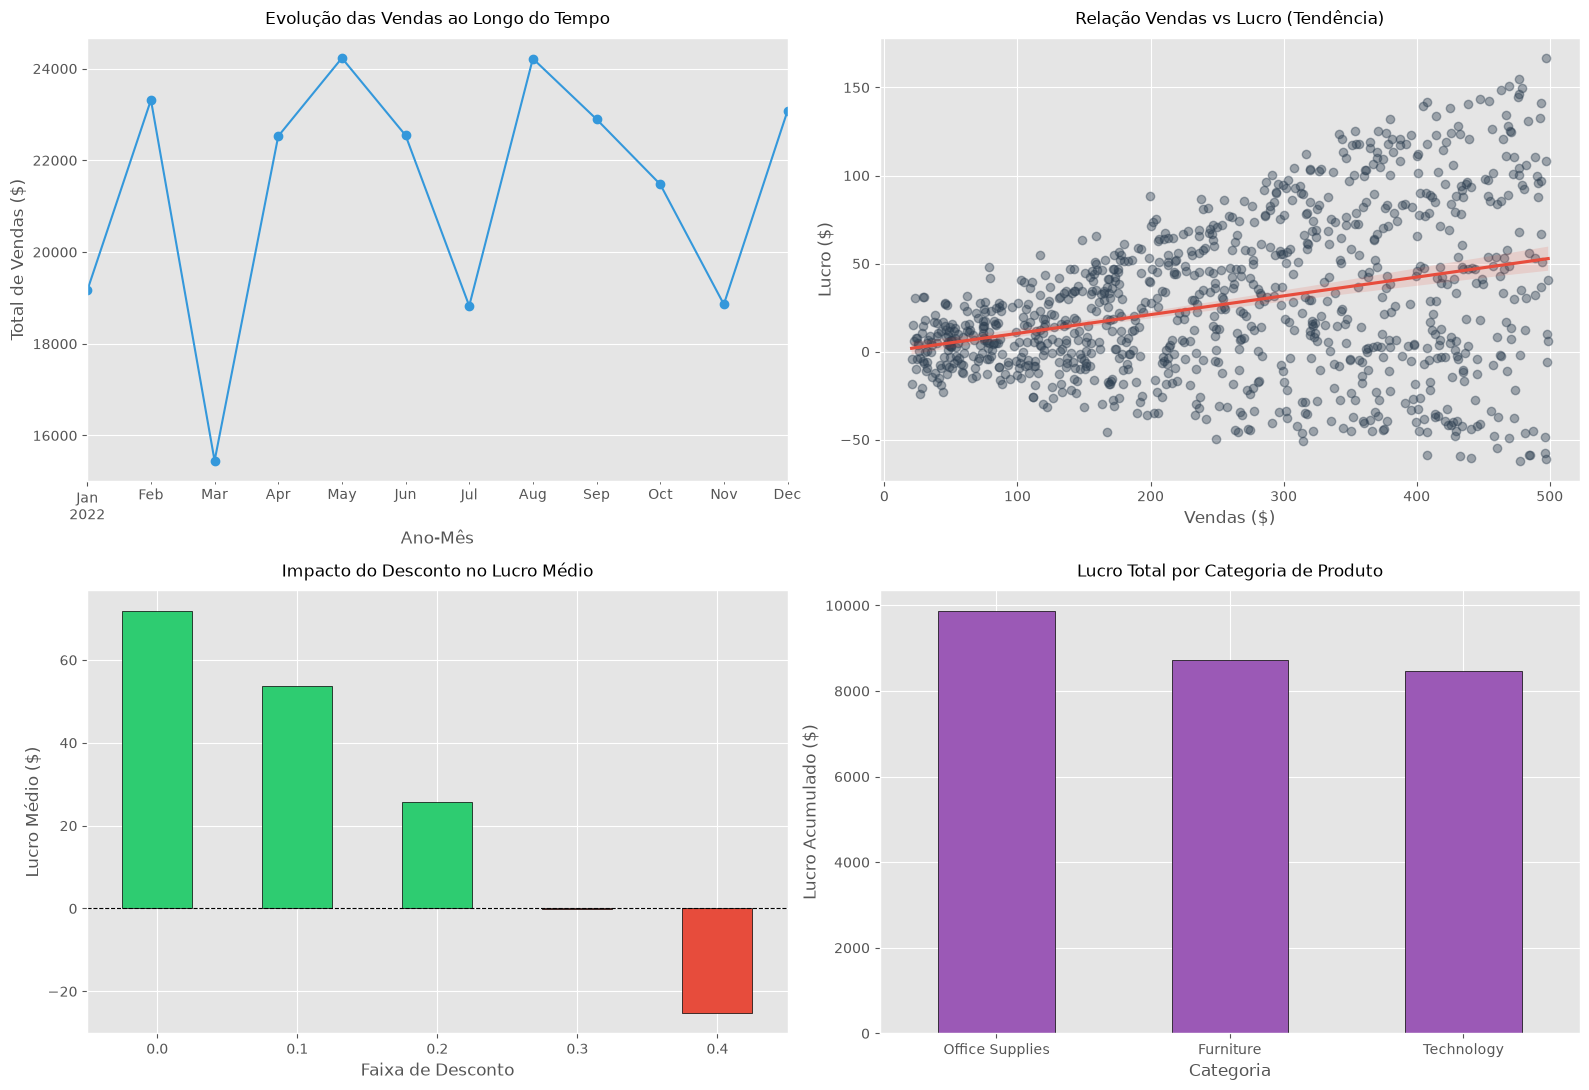

In [4]:
# ==============================================================================
# PROJETO: Análise de Vendas e Lucratividade
# OBJETIVO: Avaliar o impacto de descontos e categorias na margem de lucro
# PADRÃO: Clean Code, Portabilidade e Eficiência
# ==============================================================================

# ------------------------------------------------------------------------------
# PASSO 1: Importação de Bibliotecas e Configurações Globais
# ------------------------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define o estilo visual "ggplot" para que todos os gráficos sigam o mesmo padrão
plt.style.use('ggplot')


# ------------------------------------------------------------------------------
# PASSO 2: Carregamento Portável e Limpeza dos Dados
# ------------------------------------------------------------------------------
# O parâmetro 'parse_dates' converte as colunas de texto para data real no ato da leitura.
caminho_dados = 'data/custom_superstore_dataset.csv'
df = pd.read_csv(caminho_dados, parse_dates=['Order Date', 'Ship Date'])

# Padronização: Remove espaços em branco nas pontas (.strip()) e transforma tudo
# em letras minúsculas (.lower()). Evita erros por digitação de colunas (Ex: 'Sales ' com espaço).
df.columns = df.columns.str.strip().str.lower()


# ------------------------------------------------------------------------------
# PASSO 3: Engenharia de Recursos (Recursos Temporais)
# ------------------------------------------------------------------------------
# Extração de componentes de tempo para permitir análises sazonais e mensais.
df['year'] = df['order date'].dt.year
df['month'] = df['order date'].dt.month
df['year_month'] = df['order date'].dt.to_period('M') # Cria o formato Ano-Mês (Ex: 2022-01)

# TRATAMENTO ORTOGRÁFICO: O Pandas extrai nomes de meses em inglês. Criamos um dicionário
# para traduzi-los, mantendo a consistência com o idioma do seu README.md.
mapa_meses = {
    1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril', 5: 'Maio', 6: 'Junho',
    7: 'Julho', 8: 'Agosto', 9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro'
}
df['month_name'] = df['month'].map(mapa_meses)


# ------------------------------------------------------------------------------
# PASSO 4: Análise Estatística (Validação dos Insights)
# ------------------------------------------------------------------------------
# Exibe a matriz de correlação para provar matematicamente a relação entre as variáveis.
print("--- Matriz de Correlação ---")
print(df[['sales', 'profit', 'discount', 'quantity']].corr())
print("-" * 50)


# ------------------------------------------------------------------------------
# PASSO 5: Painel Visual Unificado (Dashboard)
# ------------------------------------------------------------------------------
# Criamos uma matriz de 2 linhas e 2 colunas para consolidar todos os gráficos.
# Isso evita gerar gráficos soltos e poluídos no histórico do notebook.
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# --- Gráfico 1 (Top-Left): Evolução das Vendas ---
vendas_temporais = df.groupby('year_month')['sales'].sum()
vendas_temporais.plot(ax=axes[0,0], marker='o', color='#3498db')
axes[0,0].set_title('Evolução das Vendas ao Longo do Tempo', fontsize=12, pad=10)
axes[0,0].set_xlabel('Ano-Mês')
axes[0,0].set_ylabel('Total de Vendas ($)')

# --- Gráfico 2 (Top-Right): Relação Vendas vs Lucro ---
# O 'sns.regplot' plota a dispersão junto com uma linha de tendência (vermelha).
# Prova o insight: A linha reta/descendente mostra que mais vendas não geram mais lucro.
sns.regplot(data=df, x='sales', y='profit', ax=axes[0,1], 
            scatter_kws={'alpha': 0.4, 'color': '#2c3e50'}, line_kws={'color': '#e74c3c'})
axes[0,1].set_title('Relação Vendas vs Lucro (Tendência)', fontsize=12, pad=10)
axes[0,1].set_xlabel('Vendas ($)')
axes[0,1].set_ylabel('Lucro ($)')

# --- Gráfico 3 (Bottom-Left): Impacto Crítico do Desconto ---
# Calculamos a média de lucro por faixa de desconto. Uma lista compreensiva define:
# Cor VERMELHA (#e74c3c) se houver prejuízo médio e VERDE (#2ecc71) se houver lucro.
lucro_desconto = df.groupby('discount')['profit'].mean()
cores_desconto = ['#e74c3c' if x < 0 else '#2ecc71' for x in lucro_desconto]

lucro_desconto.plot(kind='bar', ax=axes[1,0], color=cores_desconto, edgecolor='black')
axes[1,0].axhline(0, color='black', linewidth=0.8, linestyle='--') # Linha guia no ponto zero
axes[1,0].set_title('Impacto do Desconto no Lucro Médio', fontsize=12, pad=10)
axes[1,0].set_xlabel('Faixa de Desconto')
axes[1,0].set_ylabel('Lucro Médio ($)')
axes[1,0].tick_params(axis='x', rotation=0) # Mantém os números do eixo X na horizontal

# --- Gráfico 4 (Bottom-Right): Lucratividade por Categoria ---
# Agrupa, soma e ordena do maior lucro para o menor para facilitar a leitura visual.
lucro_categoria = df.groupby('category')['profit'].sum().sort_values(ascending=False)
lucro_categoria.plot(kind='bar', ax=axes[1,1], color='#9b59b6', edgecolor='black')
axes[1,1].set_title('Lucro Total por Categoria de Produto', fontsize=12, pad=10)
axes[1,1].set_xlabel('Categoria')
axes[1,1].set_ylabel('Lucro Acumulado ($)')
axes[1,1].tick_params(axis='x', rotation=0)

# --- Ajustes Finais do Layout ---
# O tight_layout impede que os títulos de um gráfico fiquem em cima dos eixos do outro.
plt.tight_layout()
plt.savefig('dashboard/painel_lucratividade.png', dpi=300, bbox_inches='tight')
plt.show()
